In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import label_binarize

In [46]:
# load processed data
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

class_names = ['Low', 'Moderate', 'High']
palette = {'Low': '#4CAF50', 'Moderate': '#FF9800', 'High': '#F44336'}

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

X_train: (1600, 6) | X_test: (400, 6)


In [47]:
# define models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=5,          # batasi kedalaman tree
        min_samples_leaf=10,  # cegah terlalu spesifik
        random_state=42,
        class_weight='balanced'
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        max_depth=4,          # batasi kompleksitas
        learning_rate=0.1,
        subsample=0.8,        # pakai 80% data tiap tree
        random_state=42,
        eval_metric='mlogloss',
        verbosity=0
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    )
}

for name in models:
    print(f"  - {name}")

  - Random Forest
  - XGBoost
  - Logistic Regression


In [48]:
# cross validation (k=5)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    scores = cross_validate(
        model, X_train, y_train,
        cv=cv,
        scoring=['accuracy', 'f1_macro', 'roc_auc_ovr_weighted'],
        return_train_score=True
    )
    cv_results[name] = scores
    print(f"\n{name}")
    print(f"CV Accuracy   : {scores['test_accuracy'].mean():.4f}, {scores['test_accuracy'].std():.4f}")
    print(f"CV F1 (macro) : {scores['test_f1_macro'].mean():.4f}, {scores['test_f1_macro'].std():.4f}")
    print(f"CV ROC-AUC    : {scores['test_roc_auc_ovr_weighted'].mean():.4f}, {scores['test_roc_auc_ovr_weighted'].std():.4f}")


Random Forest
CV Accuracy   : 1.0000, 0.0000
CV F1 (macro) : 1.0000, 0.0000
CV ROC-AUC    : 1.0000, 0.0000

XGBoost
CV Accuracy   : 1.0000, 0.0000
CV F1 (macro) : 1.0000, 0.0000
CV ROC-AUC    : 1.0000, 0.0000

Logistic Regression
CV Accuracy   : 0.8256, 0.0080
CV F1 (macro) : 0.8308, 0.0088
CV ROC-AUC    : 0.9375, 0.0076


In [49]:
# train final models & evaluate on test set
results = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(
        label_binarize(y_test, classes=[0,1,2]),
        y_prob, multi_class='ovr', average='weighted'
    )
    report = classification_report(y_test, y_pred,
                                   target_names=class_names, output_dict=True)

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy': acc,
        'roc_auc': roc,
        'report': report
    }

    print(f"{name} — Test Set Results")
    print(f"Accuracy : {acc:.4f}")
    print(f"ROC-AUC  : {roc:.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=class_names)}")

Random Forest — Test Set Results
Accuracy : 1.0000
ROC-AUC  : 1.0000

              precision    recall  f1-score   support

         Low       1.00      1.00      1.00        59
    Moderate       1.00      1.00      1.00       135
        High       1.00      1.00      1.00       206

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

XGBoost — Test Set Results
Accuracy : 1.0000
ROC-AUC  : 1.0000

              precision    recall  f1-score   support

         Low       1.00      1.00      1.00        59
    Moderate       1.00      1.00      1.00       135
        High       1.00      1.00      1.00       206

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

Logistic Regression — Test Set Results
Accuracy : 0.8400
ROC-AUC  : 0.9493

              precision    r

In [50]:
# Cek apakah dataset punya pola yang terlalu sempurna
df_check = pd.read_csv('../data/raw/student_lifestyle_dataset.csv')
df_check = df_check.drop(columns=['Student_ID'])

# 1. Cek apakah ada fitur yang perfectly correlated dengan target
df_check['Stress_Encoded'] = df_check['Stress_Level'].map({'Low': 0, 'Moderate': 1, 'High': 2})

features = ['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day',
            'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day',
            'Physical_Activity_Hours_Per_Day', 'GPA']

print("Correlation dengan target:")
print(df_check[features].corrwith(df_check['Stress_Encoded']).round(4).sort_values())

# 2. Cek apakah ada kombinasi fitur yang langsung menentukan kelas
print("\nSample per class:")
print(df_check.groupby('Stress_Level')[features].agg(['min', 'max']))

Correlation dengan target:
Sleep_Hours_Per_Day               -0.2989
Physical_Activity_Hours_Per_Day   -0.2052
Social_Hours_Per_Day              -0.0547
Extracurricular_Hours_Per_Day     -0.0061
GPA                                0.5504
Study_Hours_Per_Day                0.7388
dtype: float64

Sample per class:
             Study_Hours_Per_Day       Extracurricular_Hours_Per_Day       \
                             min   max                           min  max   
Stress_Level                                                                
High                         5.0  10.0                           0.0  4.0   
Low                          5.0   5.9                           0.0  4.0   
Moderate                     6.0   8.0                           0.0  4.0   

             Sleep_Hours_Per_Day       Social_Hours_Per_Day       \
                             min   max                  min  max   
Stress_Level                                                       
High                

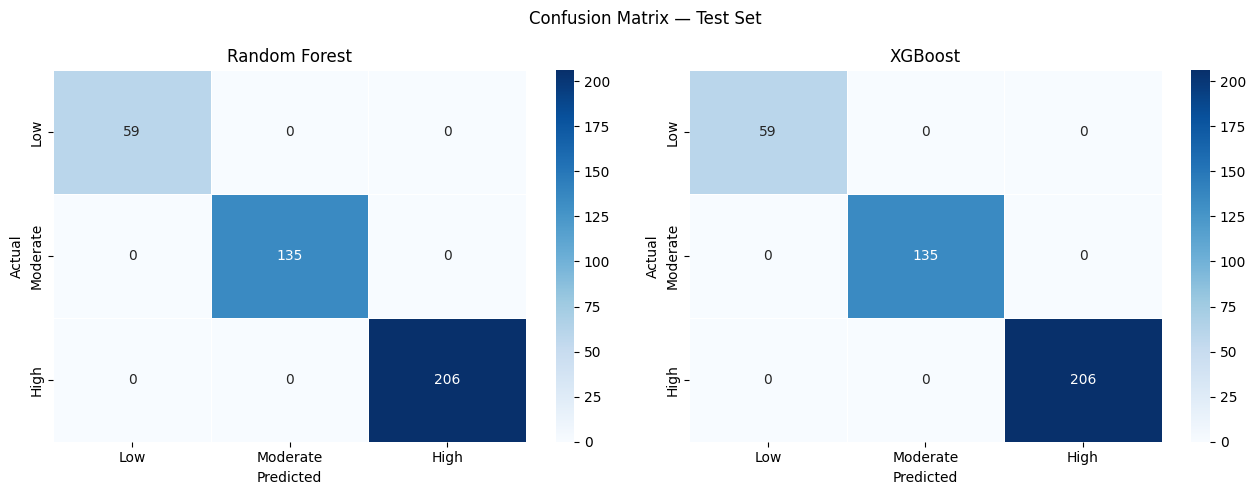

In [51]:
# confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Confusion Matrix — Test Set")

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax,
                linewidths=0.5, linecolor='white')
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix.png', bbox_inches='tight')
plt.show()

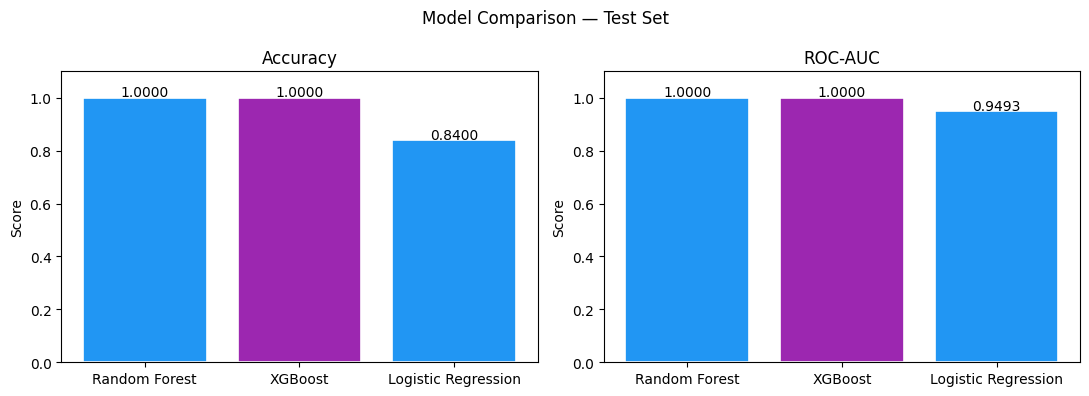

In [52]:
# model comparison chart
metrics = ['accuracy', 'roc_auc']
labels  = ['Accuracy', 'ROC-AUC']
model_names = list(results.keys())
colors = ['#2196F3', '#9C27B0']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Model Comparison — Test Set")

for ax, metric, label in zip(axes, metrics, labels):
    values = [results[n][metric] for n in model_names]
    bars = ax.bar(model_names, values, color=colors, edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
                f"{val:.4f}", ha='center')
    ax.set_title(label)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Score")

plt.tight_layout()
plt.savefig('../data/processed/model_comparison.png', bbox_inches='tight')
plt.show()

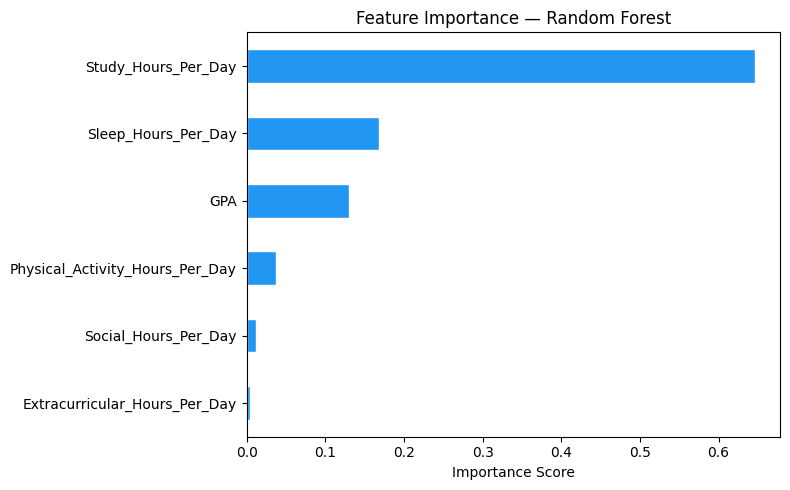

Top features:
Study_Hours_Per_Day                0.6458
Sleep_Hours_Per_Day                0.1689
GPA                                0.1302
Physical_Activity_Hours_Per_Day    0.0380
Social_Hours_Per_Day               0.0124
Extracurricular_Hours_Per_Day      0.0048
dtype: float64


In [53]:
# feature importance (Random Forest)
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_,
                         index=X_train.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='#2196F3', edgecolor='white')
ax.set_title("Feature Importance — Random Forest")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig('../data/processed/plot8_feature_importance.png', bbox_inches='tight')
plt.show()

print("Top features:")
print(importances.sort_values(ascending=False).round(4))

In [54]:
# Tentukan best model berdasarkan accuracy
best_name = max(results, key=lambda n: results[n]['accuracy'])
best_model = results[best_name]['model']

print(f"Best model: {best_name}")
print(f"Accuracy  : {results[best_name]['accuracy']:.4f}")
print(f"ROC-AUC   : {results[best_name]['roc_auc']:.4f}")

# Save model
with open('../src/model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

Best model: Random Forest
Accuracy  : 1.0000
ROC-AUC   : 1.0000


In [55]:
import os

files_to_check = [
    '../src/model.pkl',
    '../src/scaler.pkl',
    '../data/processed/X_train.csv',
    '../data/processed/X_test.csv',
    '../data/processed/y_train.csv',
    '../data/processed/y_test.csv',
    '../data/processed/df_cleaned.csv',
    '../data/processed/plot6_confusion_matrix.png',
    '../data/processed/plot7_model_comparison.png',
    '../data/processed/plot8_feature_importance.png',
]

print("File Check:")
all_ok = True
for f in files_to_check:
    exists = os.path.exists(f)
    status = "save" if exists else "missing"
    print(f"{status}  {f}")
    if not exists:
        all_ok = False

File Check:
save  ../src/model.pkl
save  ../src/scaler.pkl
save  ../data/processed/X_train.csv
save  ../data/processed/X_test.csv
save  ../data/processed/y_train.csv
save  ../data/processed/y_test.csv
save  ../data/processed/df_cleaned.csv
missing  ../data/processed/plot6_confusion_matrix.png
missing  ../data/processed/plot7_model_comparison.png
save  ../data/processed/plot8_feature_importance.png
